In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

working_dir = r'F:\Projects\Ask2.ai\Diffusion'
os.chdir(working_dir)

# Mutual Funds

In [2]:
benchmark = pd.read_csv('./warehouse/raw/benchmark_data.csv')
benchmark.rename(columns={'as_of':'date'}, inplace=True)
benchmark.set_index('date', inplace=True)
benchmark = np.log(benchmark.pct_change()+1)
benchmark = benchmark['2001-01-01':].reset_index()
benchmark.isnull().sum()

date    0
A001    0
A002    0
A003    0
A004    0
A006    0
A008    0
A009    0
A011    0
A012    0
A013    0
A014    0
A015    0
dtype: int64

In [ ]:
benchmark.to_csv('./warehouse/processed/benchmark_data_log_ret.csv', index=False)

In [2]:
benchmark = pd.read_csv('./warehouse/processed/benchmark_data_log_ret.csv')

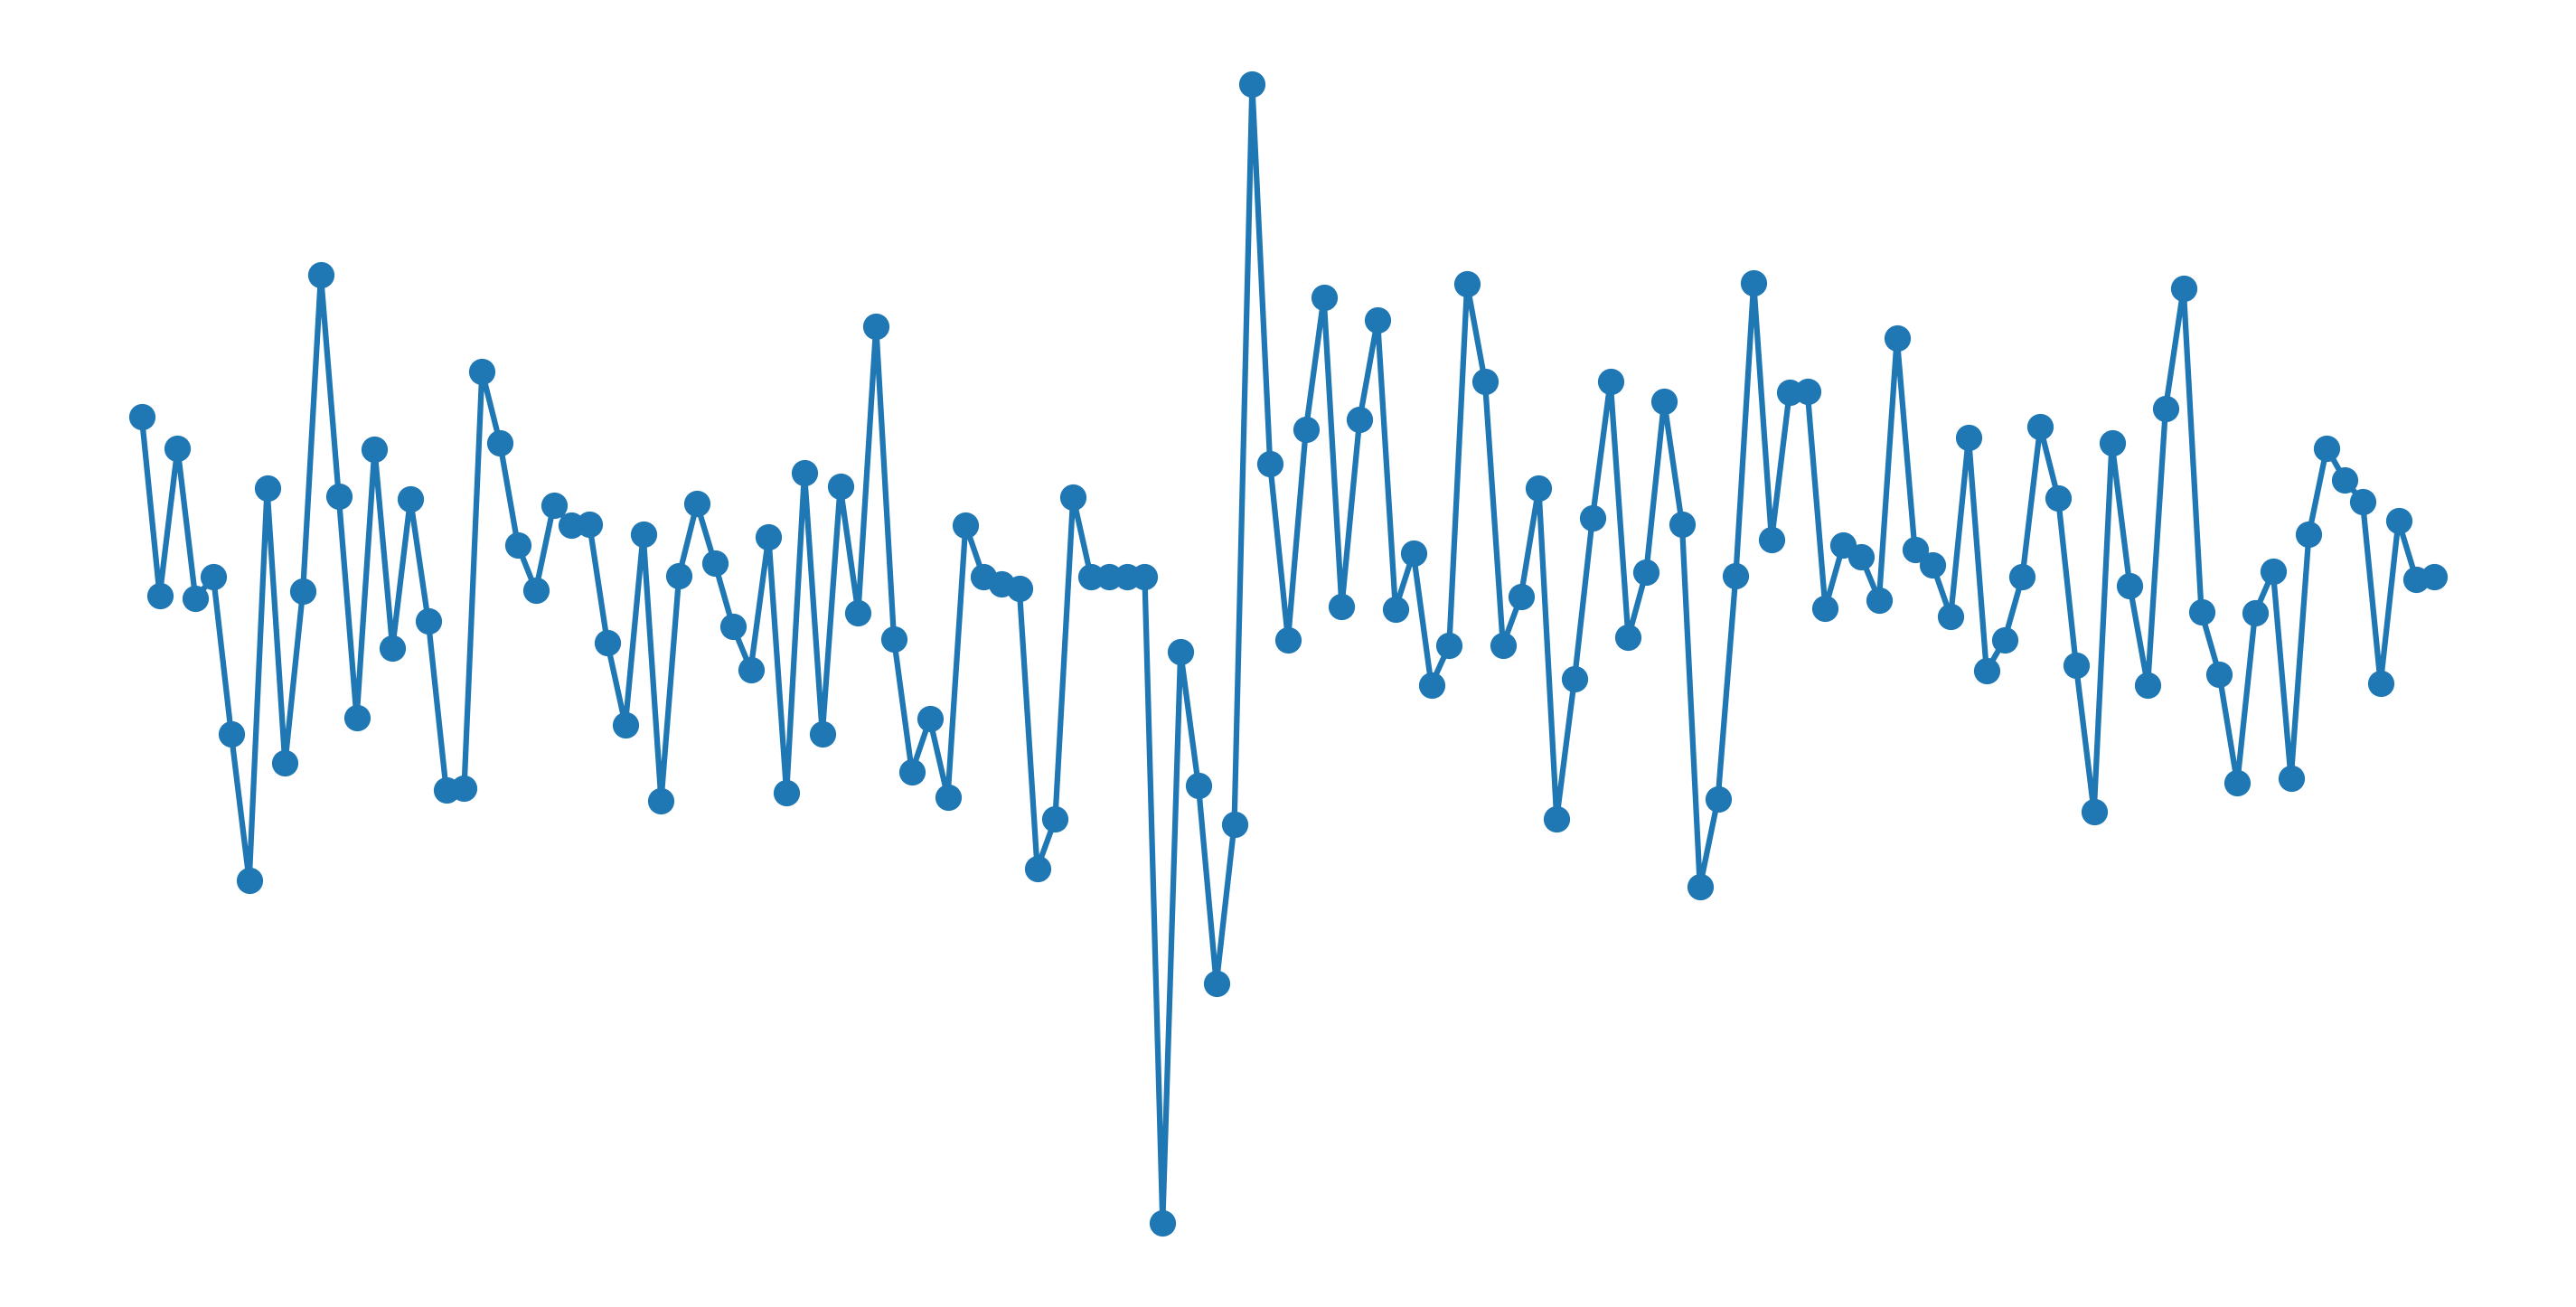

In [5]:
plt.figure(figsize=(12, 6), dpi=300)
plt.plot(benchmark.loc[128:256, 'A001'], marker='o')
plt.axis('off')
plt.show()

In [4]:
benchmark = benchmark.drop(columns=['A002', 'A003'])

In [6]:
benchmark.to_csv('./warehouse/processed/benchmark_data_log_ret_10.csv', index=False)

# PE

In [ ]:
df_benchmark_cf = pd.read_parquet('./warehouse/raw/PE Data/pe_benchmark_cashflows.parquet')
df_benchmark_cf.reset_index(inplace=True)
df_cf = pd.read_parquet('./warehouse/raw/PE Data/pe_cashflows.parquet')
df_cf.reset_index(inplace=True)
df_id = pd.read_parquet('./warehouse/raw/PE Data/pe_identifiers.parquet')

In [ ]:
df_benchmark_cf['as_of'] = pd.to_datetime(df_benchmark_cf['as_of'])
df = df_benchmark_cf[df_benchmark_cf['vintage'] == 2000]

plt.figure(figsize=(12, 6))
plt.plot(df['as_of'], df['cum_c_o_cmt'], label="cum_c_o_cmt", marker='o')
plt.plot(df['as_of'], df['cum_d_o_cmt'], label="cum_d_o_cmt", marker='o')
plt.plot(df['as_of'], df['nav_o_cmt'], label="nav_o_cmt", marker='o')

plt.xlabel("Date")
plt.ylabel("Values")
plt.title("Values Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_benchmark_cf

In [ ]:
df_cf

In [ ]:
ask_ids = df_cf['ask_id'].unique()
valid_ids = []
for ask_id in ask_ids:
    df = df_cf[df_cf['ask_id'] == ask_id]
    if df.isnull().sum().sum() > 0:
        continue
    valid_ids.append(ask_id)

In [ ]:
len(valid_ids)

In [ ]:
df_cf_valid = df_cf[df_cf['ask_id'].isin(valid_ids)]

In [ ]:
df_cf_valid.groupby('ask_id').size().sort_values(ascending=False)

In [ ]:
df = df_cf_valid[df_cf_valid['ask_id'] == valid_ids[0]]
plt.figure(figsize=(12, 6))
plt.plot(df['as_of'], df['cum_c_o_cmt'], label="cum_c_o_cmt", marker='o')
plt.plot(df['as_of'], df['cum_d_o_cmt'], label="cum_d_o_cmt", marker='o')
plt.plot(df['as_of'], df['nav_o_cmt'], label="nav_o_cmt", marker='o')

plt.xlabel("Date")
plt.ylabel("Values")
plt.title("Values Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.hist(df_cf_valid['cum_c_o_cmt'], bins=20, alpha=0.7, color='blue', edgecolor='black', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [ ]:
plt.hist(df_cf_valid['cum_d_o_cmt'], bins=20, alpha=0.7, color='blue', edgecolor='black', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [ ]:
plt.hist(df_cf_valid['nav_o_cmt'], bins=20, alpha=0.7, color='blue', edgecolor='black', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

# 2 Step Visualization

In [7]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde

In [2]:
benchmark = pd.read_csv('./warehouse/processed/benchmark_data_log_ret_10.csv')

In [28]:
from sklearn.preprocessing import QuantileTransformer

scaler = QuantileTransformer(output_distribution='normal')
ts_quantile = scaler.fit_transform(benchmark[['A001']]).reshape(-1)

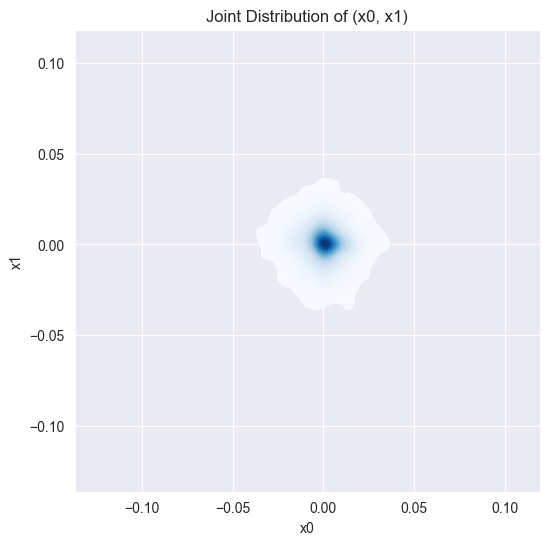

In [14]:
ts = benchmark['A001'].values
x_t0 = ts[:-1]
x_t1 = ts[1:]

plt.figure(figsize=(6, 6))
sns.kdeplot(x=x_t0, y=x_t1, fill=True, cmap="Blues", levels=30)
plt.title("Joint Distribution of (x0, x1)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.grid(True)
plt.axis("equal")
plt.show()

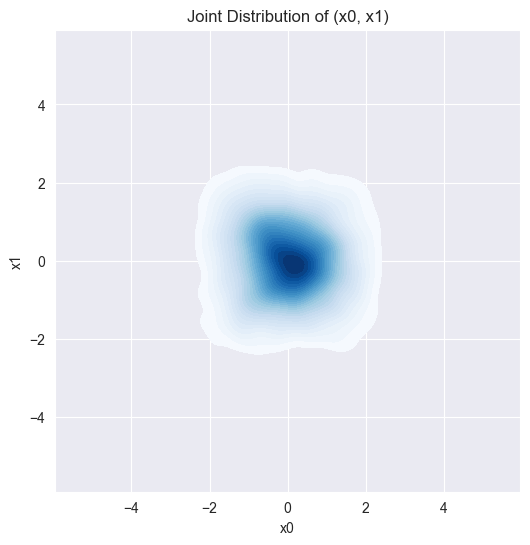

In [29]:
x_t0 = ts_quantile[:-1]
x_t1 = ts_quantile[1:]

plt.figure(figsize=(6, 6))
sns.kdeplot(x=x_t0, y=x_t1, fill=True, cmap="Blues", levels=30)
plt.title("Joint Distribution of (x0, x1)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.grid(True)
plt.axis("equal")
plt.show()

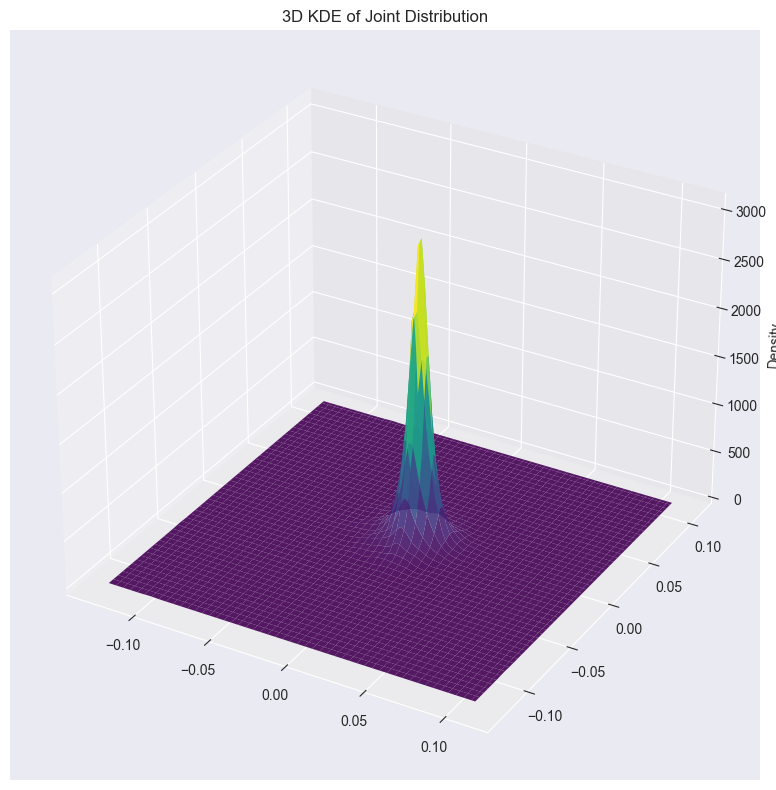

In [9]:
x_t0 = ts[:-2]
x_t2 = ts[2:]

xy = np.vstack([x_t0, x_t2])
kde = gaussian_kde(xy)
xmin, xmax = x_t0.min(), x_t0.max()
ymin, ymax = x_t2.min(), x_t2.max()
X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor='none', alpha=0.9)

ax.set_title("3D KDE of Joint Distribution")
ax.set_zlabel("Density")
plt.tight_layout()
plt.show()

In [13]:
np.corrcoef(x_t0, x_t1)

array([[ 1.        , -0.11363868],
       [-0.11363868,  1.        ]])